In [18]:
%load_ext dotenv
%dotenv

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [23]:
import os, requests
from PIL import Image
from io import BytesIO

def streetview_query_url(lat: float, lon: float, direction: int, size: int, pitch: int):
    url = 'https://maps.googleapis.com/maps/api/streetview?' + \
    ('&location=%.7f,%.7f' % (lat,lon)) + \
    ('&size=%dx%d' % (size,size)) + \
    ('&heading=%d' % direction) + \
    ('&pitch=%d' % IMG_PITCH) + \
    ('&key=%s' % os.getenv('API_KEY'))
    
    return url

def get_streetview_image(lat: float, lon: float, direction: int = 0, size : int = 640, pitch : int = 0):
    url = streetview_query_url(lat, lon, direction, size, pitch)
    r = requests.get(url)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))

In [ ]:
def has_imagery(lat: float, lon: float) -> bool:
    """
    Checks if imagery exists at a coordinate.
    """
    meta_url = (
        "https://maps.googleapis.com/maps/api/streetview/metadata"
        f"?location={lat},{lon}&key={API_KEY}"
    )
    meta = requests.get(meta_url).json()
    return meta.get("status") == "OK"

We can verify the code just using any set of coordinates, so here is a picture of the street by my apartment:

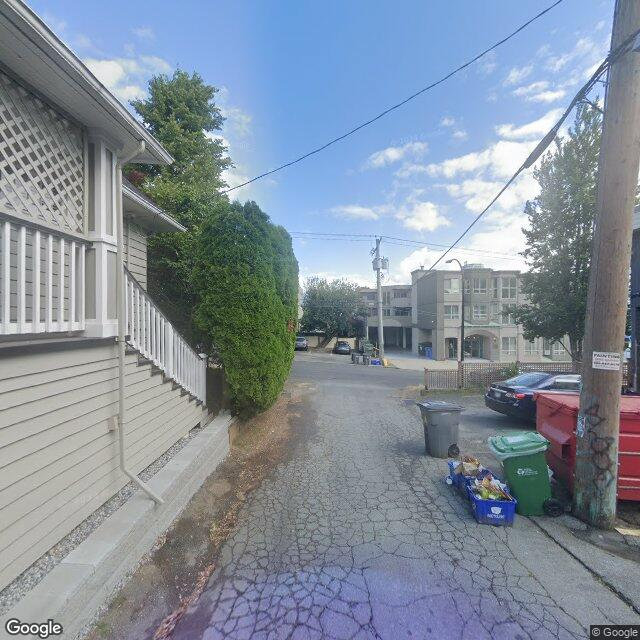

In [24]:
get_streetview_image(49.2571476, -123.1857815)

We want to randomly sample Google StreetView within the range!

In [ ]:
def random_points_in_bbox(bbox, n_points):
    """Generate random (lat, lon) points within bounding box."""
    lat_min, lat_max, lon_min, lon_max = bbox
    for _ in range(n_points):
        lat = random.uniform(lat_min, lat_max)
        lon = random.uniform(lon_min, lon_max)
        yield lat, lon

In [ ]:
def random_sample_streetview(bboxes, step=0.001, output_dir="streetview_images", delay=0.2):
    """
    Crawl a bounding box for Street View images.
    
    bbox = (lat_min, lat_max, lon_min, lon_max)
    step = degrees between sample points (0.001 approx.= 100 m)
    delay = seconds between requests to avoid quota issues
    """
    def frange(start, stop, step):
        while start <= stop:
            yield start
            start += step
    
    os.makedirs(output_dir, exist_ok=True)
    lat_min, lat_max, lon_min, lon_max = bbox

    for lat in frange(lat_min, lat_max, step):
        for lon in frange(lon_min, lon_max, step):
            if not has_imagery(lat, lon):
                print(f"No imagery at {lat:.5f}, {lon:.5f}")
                continue

            try:
                img = get_streetview_image(lat, lon)
                filename = f"{lat:.5f}_{lon:.5f}.jpg"
                img.save(os.path.join(output_dir, filename))
                print(f"Saved {filename}")
            except Exception as e:
                print(f"Failed at {lat:.5f},{lon:.5f}: {e}")
            
            time.sleep(delay)  # be kind to the API

For obtaining the test data, we can just set our testing bounding box to be within one of the two following bounding boxes:

In [ ]:
bbox = (37.7700, 37.7750, -122.4200, -122.4150)  # San Francisco example
crawl_streetview(bbox, step=0.0015)